In [1]:
import rasterio

arquivo = r"D:\Arq-Azzoni\UrbanSprawl\Bases_dados\Uso_solo_mapbiomas\brazil_coverage_2022.tif"

with rasterio.open(arquivo) as src:
    print("Arquivo:", arquivo)
    print("Largura:", src.width)
    print("Altura:", src.height)
    print("Número de bandas:", src.count)
    print("CRS:", src.crs)
    print("Tipo de dado:", src.dtypes)

    for i in range(1, src.count + 1):
        print(f"Banda {i}:")
        print("  descrição:", src.descriptions[i - 1])
        print("  dtype:", src.dtypes[i - 1])

Arquivo: D:\Arq-Azzoni\UrbanSprawl\Bases_dados\Uso_solo_mapbiomas\brazil_coverage_2022.tif
Largura: 154470
Altura: 146483
Número de bandas: 1
CRS: EPSG:4326
Tipo de dado: ('uint8',)
Banda 1:
  descrição: None
  dtype: uint8


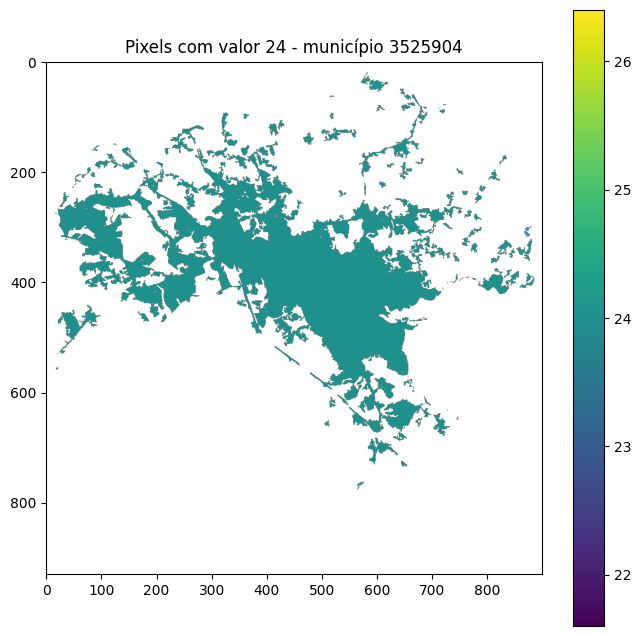

In [7]:
# ler shapefile e filtrar município
gdf = gpd.read_file(shp_municipios)
mun = gdf[gdf["CD_MUN"] == cd_mun].copy()

if mun.empty:
    raise ValueError(f'Nenhum município encontrado com CD_MUN = "{cd_mun}"')

with rasterio.open(tif_entrada) as src:
    if mun.crs != src.crs:
        mun = mun.to_crs(src.crs)

    recorte, transform = mask(src, mun.geometry, crop=True)

# pegar banda 1
banda1 = recorte[0]

# criar máscara: mantém só pixels == 24
pixels_24 = np.where(banda1 == 24, 24, np.nan)

# plotar
fig, ax = plt.subplots(figsize=(8, 8))
img = ax.imshow(pixels_24)
ax.set_title(f"Pixels com valor 24 - município {cd_mun}")
plt.colorbar(img, ax=ax)
plt.show()

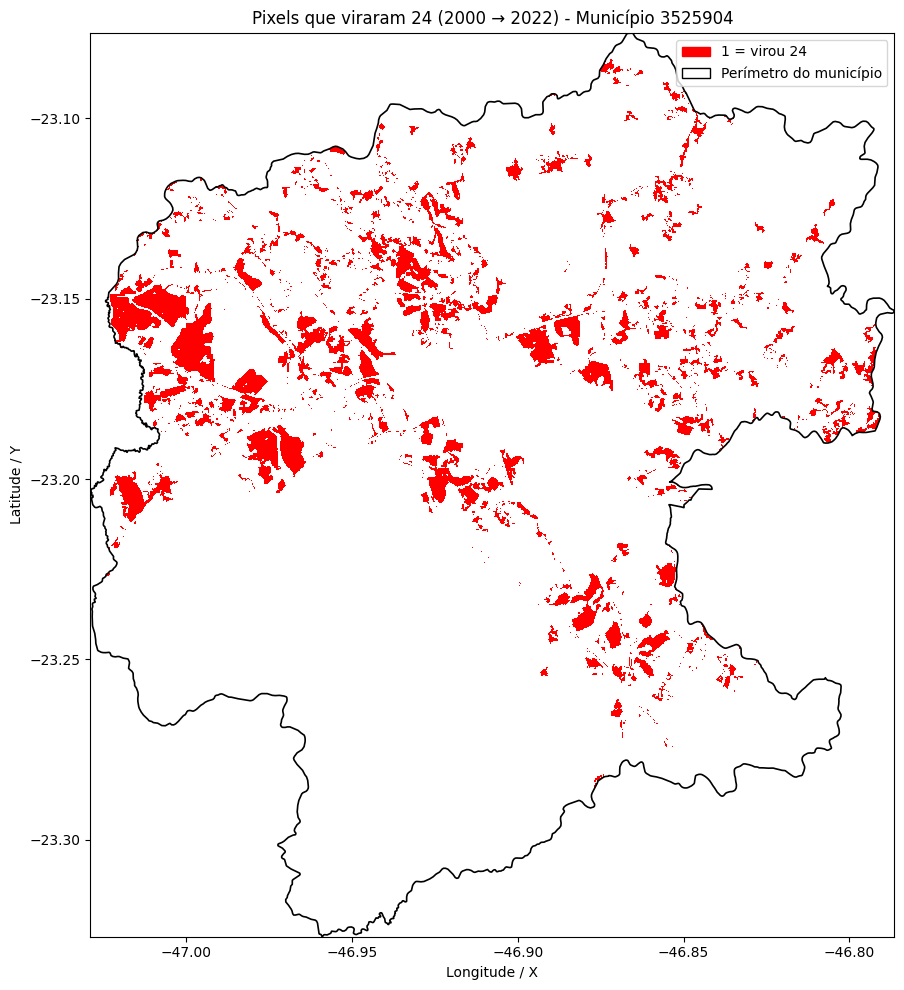

In [14]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.plot import plotting_extent
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import matplotlib.pyplot as plt
import numpy as np

shp_municipios = r"D:\Arq-Azzoni\UrbanSprawl\Bases_dados\Shapes\BR_Municipios_2024\BR_Municipios_2024.shp"

tif_2000 = r"D:\Arq-Azzoni\UrbanSprawl\Bases_dados\Uso_solo_mapbiomas\brazil_coverage_2000.tif"
tif_2022 = r"D:\Arq-Azzoni\UrbanSprawl\Bases_dados\Uso_solo_mapbiomas\brazil_coverage_2022.tif"
cd_mun = "3525904"

# ler shapefile e filtrar município
gdf = gpd.read_file(shp_municipios)
mun = gdf[gdf["CD_MUN"] == cd_mun].copy()

if mun.empty:
    raise ValueError(f'Nenhum município encontrado com CD_MUN = "{cd_mun}"')

with rasterio.open(tif_2000) as src2000, rasterio.open(tif_2022) as src2022:
    mun_2000 = mun.to_crs(src2000.crs) if mun.crs != src2000.crs else mun.copy()
    mun_2022 = mun.to_crs(src2022.crs) if mun.crs != src2022.crs else mun.copy()

    recorte_2000, transform_2000 = mask(src2000, mun_2000.geometry, crop=True)
    recorte_2022, transform_2022 = mask(src2022, mun_2022.geometry, crop=True)

    banda_2000 = recorte_2000[0]
    banda_2022 = recorte_2022[0]

    if banda_2000.shape != banda_2022.shape:
        raise ValueError(
            f"Shapes diferentes: {banda_2000.shape} vs {banda_2022.shape}. "
            "É preciso alinhar os rasters antes."
        )

    # máscara válida
    valido = np.ones(banda_2000.shape, dtype=bool)

    if src2000.nodata is not None:
        valido &= (banda_2000 != src2000.nodata)

    if src2022.nodata is not None:
        valido &= (banda_2022 != src2022.nodata)

    # 1 = não era 24 em 2000 e virou 24 em 2022
    mudou_para_24 = np.where(
        valido & (banda_2000 != 24) & (banda_2022 == 24),
        1,
        0
    ).astype("uint8")

    extent = plotting_extent(banda_2022, transform_2022)

# colormap: 0 transparente, 1 vermelho
cmap = mcolors.ListedColormap([
    (1, 1, 1, 0),   # 0 transparente
    (1, 0, 0, 1)    # 1 vermelho
])

fig, ax = plt.subplots(figsize=(10, 10))

ax.imshow(
    mudou_para_24,
    cmap=cmap,
    extent=extent,
    interpolation="nearest"
)

# perímetro do município
mun_plot = mun.to_crs(mun_2022.crs)
mun_plot.boundary.plot(ax=ax, color="black", linewidth=1.2)

ax.set_title(f"Pixels que viraram 24 (2000 → 2022) - Município {cd_mun}")
ax.set_xlabel("Longitude / X")
ax.set_ylabel("Latitude / Y")

# legenda manual
import matplotlib.patches as mpatches
legenda = [
    mpatches.Patch(color="red", label="1 = virou 24"),
    mpatches.Patch(facecolor="none", edgecolor="black", label="Perímetro do município")
]
ax.legend(handles=legenda, loc="upper right")

plt.tight_layout()
plt.show()

In [16]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import numpy as np


tif_saida = r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\uso_solo\jundiai_espraiamento_2022_2000.tif"
cd_mun = "3525904"

# ler shapefile e filtrar município
gdf = gpd.read_file(shp_municipios)
mun = gdf[gdf["CD_MUN"] == cd_mun].copy()

if mun.empty:
    raise ValueError(f'Nenhum município encontrado com CD_MUN = "{cd_mun}"')

with rasterio.open(tif_2000) as src2000, rasterio.open(tif_2022) as src2022:
    mun_2000 = mun.to_crs(src2000.crs) if mun.crs != src2000.crs else mun.copy()
    mun_2022 = mun.to_crs(src2022.crs) if mun.crs != src2022.crs else mun.copy()

    recorte_2000, _ = mask(src2000, mun_2000.geometry, crop=True)
    recorte_2022, transform = mask(src2022, mun_2022.geometry, crop=True)

    banda_2000 = recorte_2000[0]
    banda_2022 = recorte_2022[0]

    if banda_2000.shape != banda_2022.shape:
        raise ValueError(
            f"Shapes diferentes: {banda_2000.shape} vs {banda_2022.shape}. "
            "É preciso alinhar os rasters antes."
        )

    valido = np.ones(banda_2000.shape, dtype=bool)

    if src2000.nodata is not None:
        valido &= (banda_2000 != src2000.nodata)

    if src2022.nodata is not None:
        valido &= (banda_2022 != src2022.nodata)

    # 1 = não era 24 em 2000 e virou 24 em 2022
    mudou_para_24 = np.where(
        valido & (banda_2000 != 24) & (banda_2022 == 24),
        1.0,
        np.nan
    ).astype("float32")

    meta = src2022.meta.copy()
    meta.update({
        "driver": "GTiff",
        "height": mudou_para_24.shape[0],
        "width": mudou_para_24.shape[1],
        "transform": transform,
        "count": 1,
        "dtype": "float32",
        "nodata": np.nan
    })

    with rasterio.open(tif_saida, "w", **meta) as dst:
        dst.write(mudou_para_24, 1)

print(f"Arquivo salvo em: {tif_saida}")

Arquivo salvo em: D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\uso_solo\jundiai_espraiamento_2022_2000.tif


In [17]:
tif_saida = r"D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\uso_solo\jundiai_uso_solo_2000.tif"
cd_mun = "3525904"

# ler shapefile e filtrar município
gdf = gpd.read_file(shp_municipios)
mun = gdf[gdf["CD_MUN"] == cd_mun].copy()

if mun.empty:
    raise ValueError(f'Nenhum município encontrado com CD_MUN = "{cd_mun}"')

with rasterio.open(tif_2000) as src:
    if mun.crs != src.crs:
        mun = mun.to_crs(src.crs)

    recorte, transform = mask(src, mun.geometry, crop=True)
    banda_2000 = recorte[0]

    valido = np.ones(banda_2000.shape, dtype=bool)
    if src.nodata is not None:
        valido &= (banda_2000 != src.nodata)

    # 1 onde pixel == 24 em 2000; NaN no resto
    classe24_2000 = np.where(
        valido & (banda_2000 == 24),
        1.0,
        np.nan
    ).astype("float32")

    meta = src.meta.copy()
    meta.update({
        "driver": "GTiff",
        "height": classe24_2000.shape[0],
        "width": classe24_2000.shape[1],
        "transform": transform,
        "count": 1,
        "dtype": "float32",
        "nodata": np.nan
    })

    with rasterio.open(tif_saida, "w", **meta) as dst:
        dst.write(classe24_2000, 1)

print(f"Arquivo salvo em: {tif_saida}")

Arquivo salvo em: D:\Users\ivan.cavalcanti\Documents\Projects\extract_landsat\outputs\drive\uso_solo\jundiai_uso_solo_2000.tif
